# 06 — Transport panel: detectors x shifts, severity lens
The study. One frozen operating point per detector (1% FPR on deepset/direct), applied across every shift. Each cell reports how often attacks are missed (FNR), how confident those misses are (S), the over-defense rate (benign FPR), AUROC, and bootstrap 95% CIs (B=1000) on FNR and S.

**Shifts:** direct (deepset) | indirect-harmful (BIPIA scams+misinfo) | indirect-hijack (BIPIA encoding/cipher/translation) | jailbreak (jackhhao) | over-defense (NotInject, benign-only -> FPR cell).

Released detectors only (ProtectAI-v2, Prompt-Guard-2) -- the trained e5+XGBoost was shown to be a domain detector, invalid for indirect, so it is excluded.

## Bootstrap + deps + HF login

In [1]:
# === SESSION BOOTSTRAP (run first) ===
from google.colab import drive
drive.mount('/content/drive')
import os, sys
DRIVE_ROOT = '/content/drive/MyDrive/PICALIB_Research'
REPO_DIR   = os.path.join(DRIVE_ROOT, 'picalib-research')
!git config --global user.name  "Md Anas Biswas"
!git config --global user.email "anasbiswas@gmail.com"
!git config --global credential.helper "store --file={DRIVE_ROOT}/.git-credentials"
%cd {REPO_DIR}
sys.path.insert(0, 'src')
!git pull
print('Session ready.')

Mounted at /content/drive
/content/drive/MyDrive/PICALIB_Research/picalib-research
Already up to date.
Session ready.


In [2]:
!pip install -q transformers sentencepiece datasets
from huggingface_hub import login
import getpass
_t = getpass.getpass('HF token (blank = ProtectAI only): ').strip()
if _t: login(token=_t); print('logged in')
else: print('no token')

HF token (blank = ProtectAI only): ··········
logged in


## Load all shift datasets (jailbreak wrapped: skipped if unavailable)

In [3]:
import importlib, data_loaders, detectors, metrics
for m in (data_loaders, detectors, metrics): importlib.reload(m)
from data_loaders import (load_deepset, load_bipia_categorized, load_notinject,
                          load_jailbreak, BIPIA_HARMFUL, BIPIA_HIJACK, BIPIA_MALICIOUS)
from detectors import score_released, threshold_at_fpr, auroc
import numpy as np, pandas as pd, os

deepset = load_deepset()
bip     = load_bipia_categorized(per_category=30, categories=BIPIA_MALICIOUS)  # matches nb05 cache
noti    = load_notinject()
try:
    jb = load_jailbreak(); print('jailbreak:', len(jb), 'rows')
except Exception as e:
    jb = None; print('[skip jailbreak]', e)
print('deepset', len(deepset), '| bipia', len(bip), '| notinject', len(noti))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/500 [00:00<?, ?B/s]

data/train-00000-of-00001-9564e8b05b4757(…):   0%|          | 0.00/40.3k [00:00<?, ?B/s]

data/test-00000-of-00001-701d16158af8736(…):   0%|          | 0.00/10.9k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/546 [00:00<?, ? examples/s]

...

jailbreak_dataset_train_balanced.csv:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

jailbreak_dataset_test_balanced.csv:   0%|          | 0.00/370k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1044 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/262 [00:00<?, ? examples/s]

jailbreak: 794 rows
deepset 662 | bipia 988 | notinject 339


## Score each detector on each shift (caches reused where present)

In [4]:
DETECTORS = {'protectai_v2':'protectai/deberta-v3-base-prompt-injection-v2',
             'prompt_guard_2':'meta-llama/Llama-Prompt-Guard-2-86M'}
os.makedirs('data', exist_ok=True)
FRAMES = {'deepset':deepset, 'bipia_cat':bip, 'notinject':noti}
if jb is not None: FRAMES['jailbreak'] = jb

def score_cached(tag, name, key, texts):
    fp = f'data/score_{tag}_{key}.npy'
    if os.path.exists(fp): return np.load(fp)
    p = score_released(texts, name); np.save(fp, p); return p

P = {}
for tag, name in DETECTORS.items():
    try:
        P[tag] = {k: score_cached(tag, name, k, f.text.tolist()) for k,f in FRAMES.items()}
        print(f'{tag}: scored {list(P[tag].keys())}')
    except Exception as e:
        print(f'[skip] {tag}: {e}')

config.json:   0%|          | 0.00/994 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.28k [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/8.66M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

  meta-llama/Llama-Prompt-Guard-2-86M: id2label={0: 'LABEL_0', 1: 'LABEL_1'} -> attack class index 1


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

  meta-llama/Llama-Prompt-Guard-2-86M: id2label={0: 'LABEL_0', 1: 'LABEL_1'} -> attack class index 1
prompt_guard_2: scored ['deepset', 'bipia_cat', 'notinject', 'jailbreak']


In [13]:
DETECTORS['prompt_guard_2_22m'] = 'meta-llama/Llama-Prompt-Guard-2-22M'
tag, name = 'prompt_guard_2_22m', DETECTORS['prompt_guard_2_22m']
try:
    P[tag] = {k: score_cached(tag, name, k, f.text.tolist()) for k,f in FRAMES.items()}
    print(f'{tag}: scored {list(P[tag].keys())}')
except Exception as e:
    print(f'[skip] {tag}: {e}')
print('detectors now in P:', list(P.keys()))

config.json:   0%|          | 0.00/870 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.28k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/8.66M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/283M [00:00<?, ?B/s]

...

  meta-llama/Llama-Prompt-Guard-2-22M: id2label={0: 'LABEL_0', 1: 'LABEL_1'} -> attack class index 1


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

  meta-llama/Llama-Prompt-Guard-2-22M: id2label={0: 'LABEL_0', 1: 'LABEL_1'} -> attack class index 1


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

  meta-llama/Llama-Prompt-Guard-2-22M: id2label={0: 'LABEL_0', 1: 'LABEL_1'} -> attack class index 1
prompt_guard_2_22m: scored ['deepset', 'bipia_cat', 'notinject', 'jailbreak']
detectors now in P: ['protectai_v2', 'prompt_guard_2', 'prompt_guard_2_22m']


## Per-cell metrics + bootstrap CIs

In [14]:
def cell_metrics(y, p, t, B=1000, seed=0, min_misses=10):
    y=np.asarray(y); p=np.asarray(p); rng=np.random.default_rng(seed)
    atk = y==1; ben = y==0
    out={'n_atk':int(atk.sum()),'n_ben':int(ben.sum())}
    out['benign_FPR'] = float((p[ben]>=t).mean()) if ben.sum() else np.nan
    out['AUROC'] = auroc(y,p) if (atk.sum() and ben.sum()) else np.nan
    if atk.sum():
        pa=p[atk]; miss=pa<t
        out['FNR']=float(miss.mean()); out['n_misses']=int(miss.sum())
        out['S']=float(np.mean(1-pa[miss])) if miss.sum()>=min_misses else np.nan
        Ss=[]; Fs=[]
        for _ in range(B):
            idx=rng.integers(0,len(pa),len(pa)); pr=pa[idx]; mr=pr<t
            Fs.append(mr.mean())
            Ss.append(np.mean(1-pr[mr]) if mr.sum()>=min_misses else np.nan)
        out['FNR_lo'],out['FNR_hi']=np.percentile(Fs,[2.5,97.5])
        out['S_lo'],out['S_hi']=np.nanpercentile(Ss,[2.5,97.5])
    else:
        out.update({'FNR':np.nan,'n_misses':0,'S':np.nan,'FNR_lo':np.nan,'FNR_hi':np.nan,'S_lo':np.nan,'S_hi':np.nan})
    return out

def cells_for(tag):
    f=FRAMES; p=P[tag]
    t=threshold_at_fpr(p['deepset'][f['deepset'].label.values==0],0.01)
    bipben = f['bipia_cat'].label.values==0
    H = f['bipia_cat'].meta.isin(BIPIA_HARMFUL).values
    J = f['bipia_cat'].meta.isin(BIPIA_HIJACK).values
    cells={}
    cells['direct']=(f['deepset'].label.values, p['deepset'])
    yh=np.r_[np.ones(H.sum()),np.zeros(bipben.sum())]; ph=np.r_[p['bipia_cat'][H],p['bipia_cat'][bipben]]
    cells['indirect_harmful']=(yh,ph)
    yj=np.r_[np.ones(J.sum()),np.zeros(bipben.sum())]; pj=np.r_[p['bipia_cat'][J],p['bipia_cat'][bipben]]
    cells['indirect_hijack']=(yj,pj)
    if 'jailbreak' in p: cells['jailbreak']=(f['jailbreak'].label.values, p['jailbreak'])
    cells['over_defense']=(f['notinject'].label.values, p['notinject'])
    return t, cells

panel=[]
for tag in P:
    t,cells=cells_for(tag)
    for shift,(y,p) in cells.items():
        m=cell_metrics(y,p,t); m.update({'detector':tag,'shift':shift,'t':round(float(t),4)})
        panel.append(m)
cols=['detector','shift','t','n_atk','n_ben','FNR','FNR_lo','FNR_hi','S','S_lo','S_hi','n_misses','benign_FPR','AUROC']
P_df=pd.DataFrame(panel)[cols].round(3)
print(P_df.to_string(index=False))

          detector            shift     t  n_atk  n_ben   FNR  FNR_lo  FNR_hi     S  S_lo  S_hi  n_misses  benign_FPR  AUROC
      protectai_v2           direct 0.028    263    399 0.548   0.483   0.605 0.999 0.998 0.999       144       0.010  0.882
      protectai_v2 indirect_harmful 0.028     60    778 0.650   0.533   0.767 0.995 0.993 0.997        39       0.397  0.444
      protectai_v2  indirect_hijack 0.028    150    778 0.693   0.620   0.767 0.993 0.992 0.995       104       0.397  0.424
      protectai_v2        jailbreak 0.028    396    398 0.136   0.104   0.169 0.995 0.993 0.997        54       0.013  0.986
      protectai_v2     over_defense 0.028      0    339   NaN     NaN     NaN   NaN   NaN   NaN         0       0.460    NaN
    prompt_guard_2           direct 0.004    263    399 0.532   0.468   0.593 0.999 0.999 0.999       140       0.010  0.942
    prompt_guard_2 indirect_harmful 0.004     60    778 0.217   0.117   0.333 0.998 0.997 0.998        13       0.145  0.894


## Heatmaps: S and FNR across detector x shift

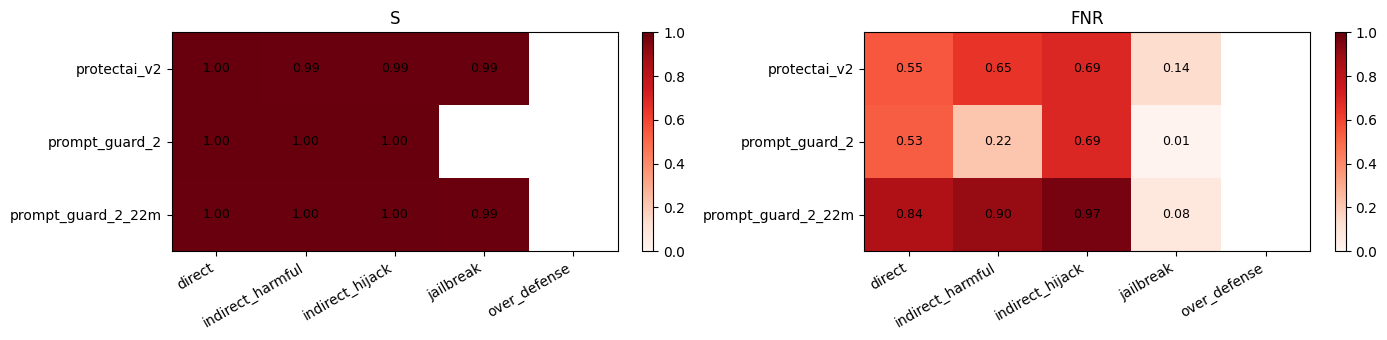

In [15]:
import matplotlib.pyplot as plt
order=['direct','indirect_harmful','indirect_hijack','jailbreak','over_defense']
dets=list(P.keys())
def grid(metric):
    M=np.full((len(dets),len(order)),np.nan)
    for _,r in P_df.iterrows():
        if r['shift'] in order: M[dets.index(r['detector']),order.index(r['shift'])]=r[metric]
    return M
fig,axes=plt.subplots(1,2,figsize=(14,1.4+0.7*len(dets)))
for ax,metric in zip(axes,['S','FNR']):
    M=grid(metric); im=ax.imshow(M,cmap='Reds',vmin=0,vmax=1,aspect='auto')
    ax.set_xticks(range(len(order))); ax.set_xticklabels(order,rotation=30,ha='right')
    ax.set_yticks(range(len(dets))); ax.set_yticklabels(dets)
    ax.set_title(metric)
    for i in range(len(dets)):
        for j in range(len(order)):
            if not np.isnan(M[i,j]): ax.text(j,i,f'{M[i,j]:.2f}',ha='center',va='center',fontsize=9)
    fig.colorbar(im,ax=ax,fraction=0.046)
plt.tight_layout(); os.makedirs('figures',exist_ok=True)
plt.savefig('figures/transport_panel_heatmap.png',dpi=150); plt.show()

## Read + persist + commit
S near 1.0 with high FNR = confident misses. AUROC drop direct->shift = discrimination loss. benign_FPR on over_defense = over-defense rate.

In [16]:
from reslog import log_result
import numpy as np
lines=['TRANSPORT PANEL READ:']
for tag in P:
    d=P_df[P_df['detector']==tag]
    base=d[d['shift']=='direct']
    if len(base): lines.append(f"[{tag}] direct: FNR={base.FNR.values[0]}, AUROC={base.AUROC.values[0]}")
    for sh in ['indirect_harmful','indirect_hijack','jailbreak']:
        r=d[d['shift']==sh]
        if len(r) and not np.isnan(r.S.values[0]):
            lines.append(f"   {sh}: FNR={r.FNR.values[0]} S={r.S.values[0]} (CI {r.S_lo.values[0]}-{r.S_hi.values[0]}) misses={int(r.n_misses.values[0])}")
    od=d[d['shift']=='over_defense']
    if len(od): lines.append(f"   over_defense benign_FPR={od.benign_FPR.values[0]}")
read='\n'.join(lines)
print(read)
P_df.to_csv('reports/transport_panel.csv',index=False)
body = P_df.to_string(index=False) + '\n\n' + read
log_result('Transport panel (detectors x shifts, severity + bootstrap CIs)', body, csv_df=P_df, csv_name='transport_panel.csv')

!git add -A
!git commit -m "Transport panel: detectors x shifts with FNR/S/benignFPR/AUROC + bootstrap CIs"
!git push
print('Pushed.')

TRANSPORT PANEL READ:
[protectai_v2] direct: FNR=0.548, AUROC=0.882
   indirect_harmful: FNR=0.65 S=0.995 (CI 0.993-0.997) misses=39
   indirect_hijack: FNR=0.693 S=0.993 (CI 0.992-0.995) misses=104
   jailbreak: FNR=0.136 S=0.995 (CI 0.993-0.997) misses=54
   over_defense benign_FPR=0.46
[prompt_guard_2] direct: FNR=0.532, AUROC=0.942
   indirect_harmful: FNR=0.217 S=0.998 (CI 0.997-0.998) misses=13
   indirect_hijack: FNR=0.693 S=0.998 (CI 0.998-0.998) misses=104
   over_defense benign_FPR=0.192
[prompt_guard_2_22m] direct: FNR=0.837, AUROC=0.777
   indirect_harmful: FNR=0.9 S=0.996 (CI 0.995-0.996) misses=54
   indirect_hijack: FNR=0.967 S=0.996 (CI 0.996-0.997) misses=145
   jailbreak: FNR=0.083 S=0.99 (CI 0.988-0.992) misses=33
   over_defense benign_FPR=0.13
[reslog] appended 'Transport panel (detectors x shifts, severity + bootstrap CIs)' to reports/RESULTS_LOG.md + transport_panel.csv
[main e8bdfef] Transport panel: detectors x shifts with FNR/S/benignFPR/AUROC + bootstrap CIs


In [11]:
!git add -A
!git commit -m "Transport panel: detectors x shifts with FNR/S/benignFPR/AUROC + bootstrap CIs"
!git push
print('Pushed.')

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date
Pushed.


In [12]:
import numpy as np
from reslog import log_result
# CI-consistency: below the min_misses floor, S is "not estimable" -> its CI must be NaN too
mask = P_df['n_misses'] < 10
P_df.loc[mask, ['S','S_lo','S_hi']] = np.nan
print(P_df[['detector','shift','n_misses','S','S_lo','S_hi']].to_string(index=False))
P_df.to_csv('reports/transport_panel.csv', index=False)
log_result('Transport panel (CI-consistency: S+CI suppressed when misses<10)', P_df.to_string(index=False), csv_df=P_df, csv_name='transport_panel.csv')
!git add -A && git commit -m "CI-consistency: suppress S and its CI when n_misses<10" && git push
print('done')

      detector            shift  n_misses     S  S_lo  S_hi
  protectai_v2           direct       144 0.999 0.998 0.999
  protectai_v2 indirect_harmful        39 0.995 0.993 0.997
  protectai_v2  indirect_hijack       104 0.993 0.992 0.995
  protectai_v2        jailbreak        54 0.995 0.993 0.997
  protectai_v2     over_defense         0   NaN   NaN   NaN
prompt_guard_2           direct       140 0.999 0.999 0.999
prompt_guard_2 indirect_harmful        13 0.998 0.997 0.998
prompt_guard_2  indirect_hijack       104 0.998 0.998 0.998
prompt_guard_2        jailbreak         4   NaN   NaN   NaN
prompt_guard_2     over_defense         0   NaN   NaN   NaN
[reslog] appended 'Transport panel (CI-consistency: S+CI suppressed when misses<10)' to reports/RESULTS_LOG.md + transport_panel.csv
[main 13067c3] CI-consistency: suppress S and its CI when n_misses<10
 3 files changed, 21 insertions(+), 2 deletions(-)
Enumerating objects: 13, done.
Counting objects: 100% (13/13), done.
Delta compression